In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for all charts
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

# Load data
sales = pd.read_csv("D:\\Datathon\\data\\sales.csv")
sales['Date'] = pd.to_datetime(sales['Date'])

# Monthly Aggregation
monthly = sales.groupby(pd.Grouper(key='Date', freq='ME')).agg({
    'Revenue': 'sum',
    'COGS': 'sum'
}).reset_index()

monthly['Profit'] = monthly['Revenue'] - monthly['COGS']
monthly['margin_profit'] = monthly['Profit'] / monthly['Revenue']

Data loaded and monthly metrics calculated.


## 1. Monthly Revenue and Profit Trend
Analyzing the long-term trajectory of financial performance.

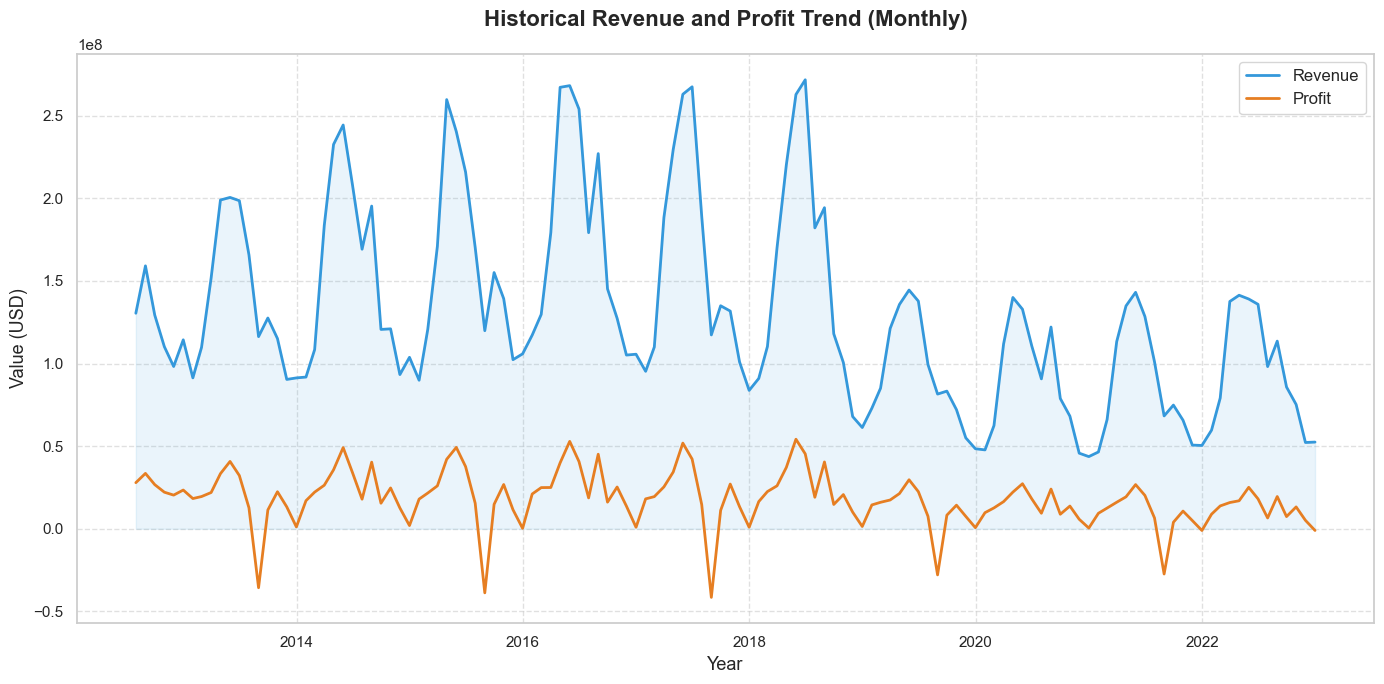

In [11]:
plt.figure(figsize=(14, 7))
plt.plot(monthly['Date'], monthly['Revenue'], label='Revenue', color='#3498db', linewidth=2)
plt.plot(monthly['Date'], monthly['Profit'], label='Profit', color='#e67e22', linewidth=2)
plt.fill_between(monthly['Date'], monthly['Revenue'], alpha=0.1, color='#3498db')

plt.title("Historical Revenue and Profit Trend (Monthly)", fontsize=16, weight='bold', pad=20)
plt.xlabel("Year", fontsize=13)
plt.ylabel("Value (USD)", fontsize=13)
plt.legend(frameon=True, fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 2. Seasonal Revenue Patterns
Identifying high-performance months to optimize resource allocation.

C:\Users\Administrator\AppData\Local\Temp\ipykernel_9396\719663519.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='month', y='Revenue', data=seasonality, color='#2980b9', palette='Blues_d')


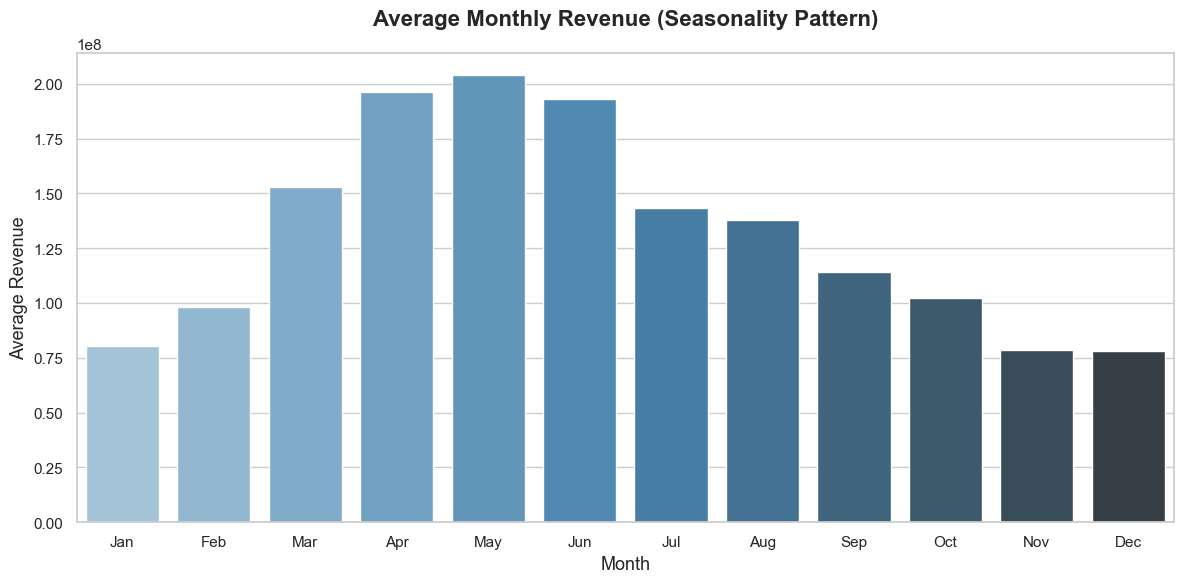

In [12]:
monthly['month'] = monthly['Date'].dt.month
seasonality = monthly.groupby('month')['Revenue'].mean().reset_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(12, 6))
sns.barplot(x='month', y='Revenue', data=seasonality, color='#2980b9', palette='Blues_d')

plt.title("Average Monthly Revenue (Seasonality Pattern)", fontsize=16, weight='bold', pad=20)
plt.xlabel("Month", fontsize=13)
plt.ylabel("Average Revenue", fontsize=13)
plt.xticks(range(0, 12), month_names)
plt.tight_layout()
plt.show()

## 3. Yearly Revenue Growth Percentage
Measuring the velocity of business expansion year-over-year.

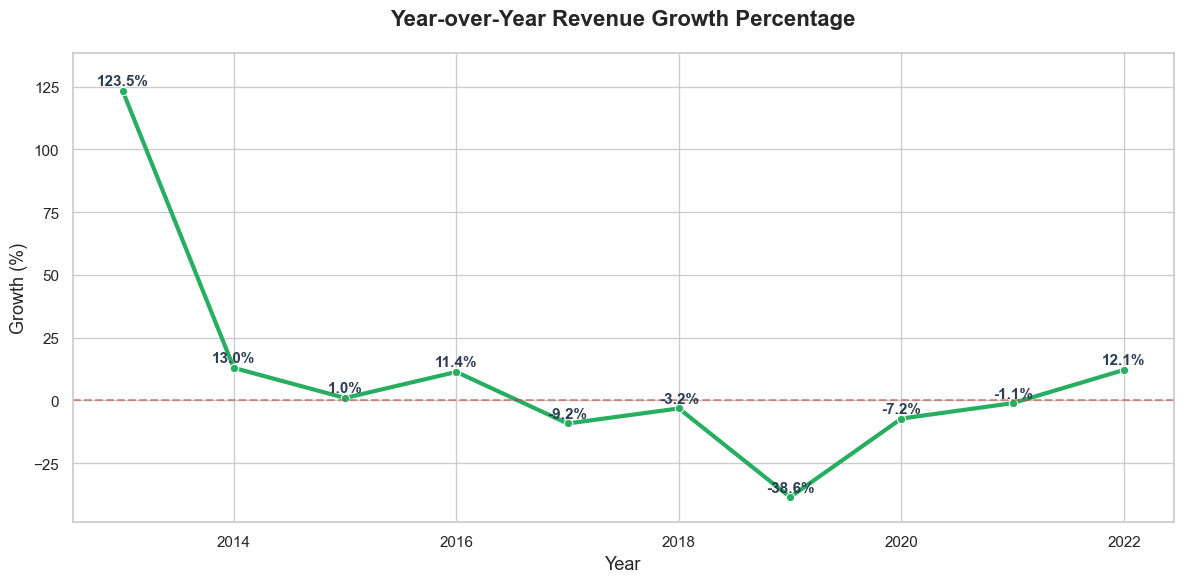

In [13]:
monthly['year'] = monthly['Date'].dt.year
yearly_revenue = monthly.groupby('year')['Revenue'].sum().reset_index()
yearly_revenue['Growth (%)'] = yearly_revenue['Revenue'].pct_change() * 100

plt.figure(figsize=(12, 6))
ax = sns.lineplot(x='year', y='Growth (%)', data=yearly_revenue.dropna(), marker='o', color='#27ae60', linewidth=3)
plt.axhline(0, color='#c0392b', linestyle='--', alpha=0.5)

# Add data labels
for i, row in yearly_revenue.dropna().iterrows():
    ax.text(row['year'], row['Growth (%)'] + 1, f"{row['Growth (%)']:.1f}%", 
            ha='center', va='bottom', fontsize=11, weight='bold', color='#2c3e50')

plt.title("Year-over-Year Revenue Growth Percentage", fontsize=16, weight='bold', pad=20)
plt.xlabel("Year", fontsize=13)
plt.ylabel("Growth (%)", fontsize=13)
plt.ylim(yearly_revenue['Growth (%)'].min() - 10, yearly_revenue['Growth (%)'].max() + 15)
plt.tight_layout()
plt.show()